# EXPLORATORY DATA ANALYSIS (EDA)



### The main purpose:

- Summarize main characteristics of the data (Tóm tắt các đặc điểm chính của dữ liệu)

- Gain better understanding of the data set (Tiếp cận - hiểu sâu hơn về dataset)

- Uncover relationships between variables (Mở ra những kết nối giữa các biến)

- Extract important variables (Trích xuất các biến quan trọng)



**Question: What are the characteristics of the data which have the most impact of the dataset**

*Chúng ta nên đặt câu hỏi là biến nào có ảnh hưởng lớn nhất trong dataset*

# DESCRIPTIVE STATICTIS 

### What is a descriptive statistics? 

- We must explore data before use it in model 

- Calculate descriptive statistics for all data

- Describe a basic summary of dataset

- Giving short summaries about the sample and measurea of the data

### Method - Function - Syntax

`df.describe()` --> give you a clear idea of the distribution of your different variables

`categorical_count = df["the_column_you_want_to_count_the_catagories"].value_counts()` --> count the number of differnt value

For examples: If i have a columns name "M&M Candy", value.count() will response a list like: 15 red bags, 10 yellow bags, 5 orange bags



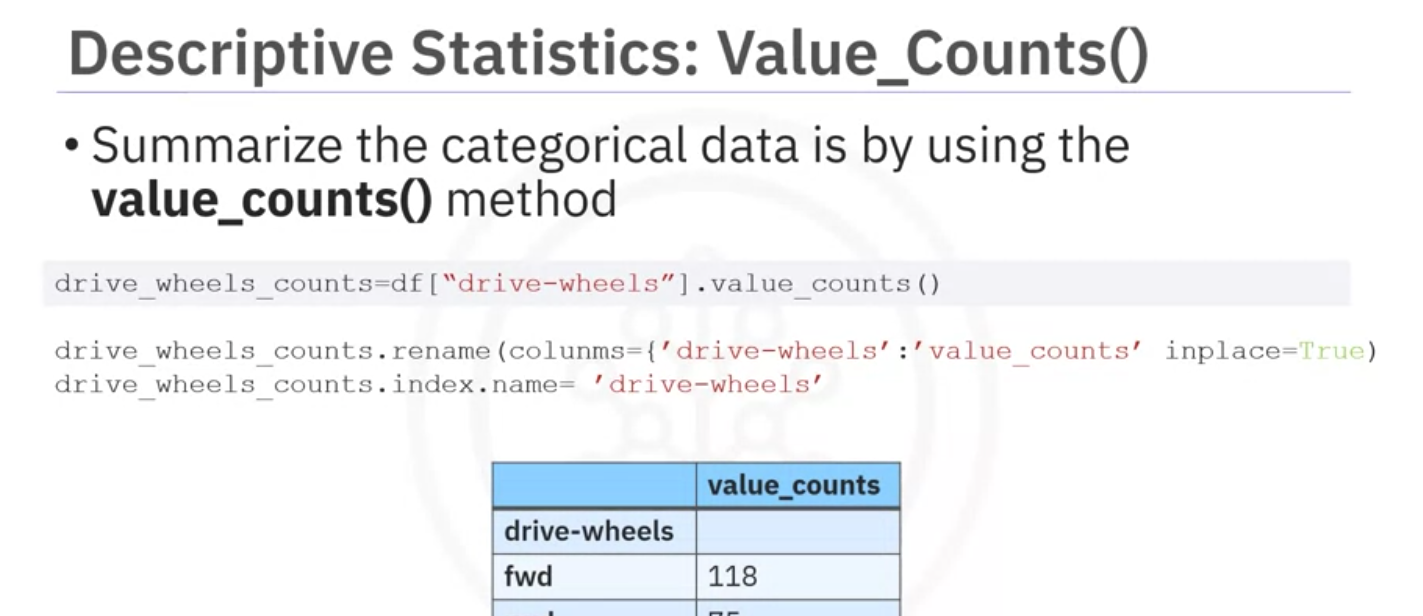

Nếu không có dòng cuối thì bảng in ra của `value_counts()` nhưng mà nó sẽ bị sai tên - do Pandas không tự đặt tên theo mình muốn mà Pandas đặt tên theo cột mà mình kêu value_counts()

Giải thích thêm: Ở dòng 1 thì Pandas đã tóm lại số lượng các giá trị có ở trong list ["drive-wheels] -- Hiểu ở đây chưa?

Cơ chế hoạt động của Pandas sẽ xuất ra 1 cái bảng khi mà nó count categorical cho mình - NHƯNG cột số lượng đó Pandas sẽ đặt tên là ["drive_wheels"] -- thì về mặt tính chất là sai - do ở cột đó đang chứa số lượng của các categorical 

Nên mình cần rename lại ở dòng 2, rồi lệnh `.index` để chỉ thẳng vào vị trí trên cùng của cột chứa fwd - rwd - ... để `.name` đặt tên là drive-wheels

### BOX PLOTS

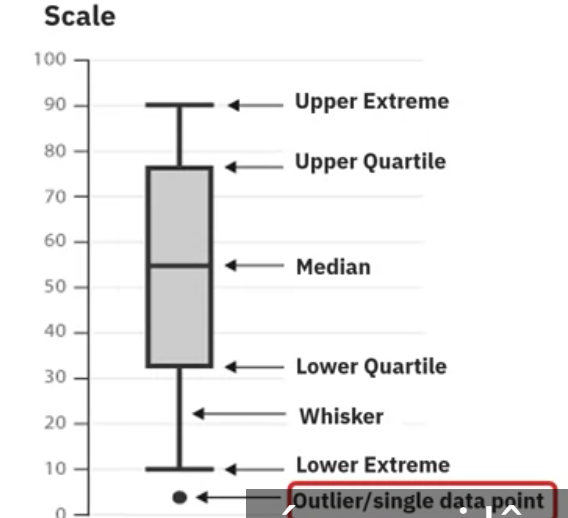

Median : Số trung bình 

Quartile : represents the interquartile range

Lower - Upper / Extreme : calculates as 1.5 times the inner-quartile range above the 75%, as 1.5 times the inner-quartile range below the 25% 

### Box Plots SYNTAX

`sns.boxplot (x= "Lables or Category Name", y = "The quantity - The number", data = df)`


### Scatter Plot 

**Each observation represent as a point**

**Show the relationship between two viriables**

**- Predictor / Independent variables on x-axis** (Biến mà bạn sử dụng để dự đoán kết quả)

**- Target / dependent variables on y-axis** (Biến mà bạn cố gắng dự đoán)

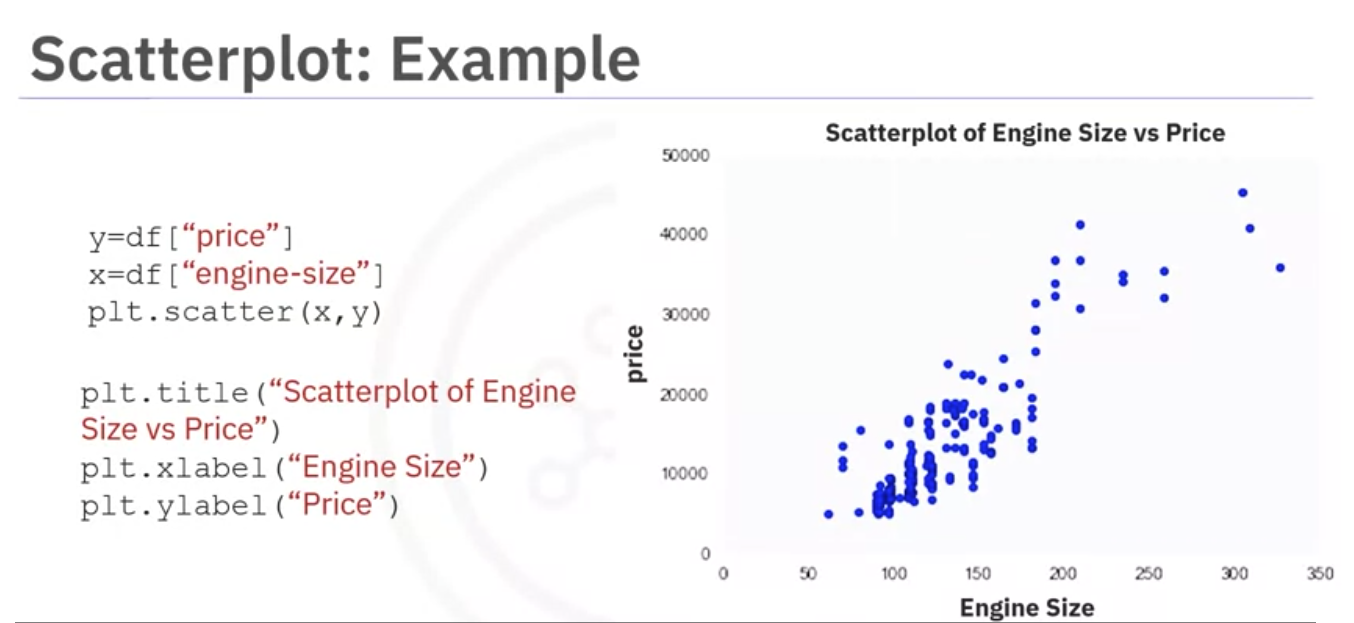

`plt.scatter (x,y)`

For example: 

y value is a variable we wants to predict --> the price

x value is a variable we use to predict --> the engine-size

but the map just hit the air since there are no lable in this graph

`plt.title ("NAME OF THE GRAPH")` to name the graph

`plt.xlabel("NAME OF THE X-AXIS)` to name the x-axis

`plt.ylabel("NAME OF THE Y-AXIS)` to name the y-axis

# GROUPING AND PIVOTING DATA

### What is grouping and pivoting?
- We must explore the relationship between categorical variables and target variable
- Group all the data by different types of categories and compare the results
- Transform the table into a rectangular grid (pivot table) to make it easier to read and visualize
- Use Heat Map to get visual clues of the relationship based on color intensity

### Method - Function - Syntax

`grouped_data = df.groupby(["column_1", "column_2"], as_index=False).mean()` --> group data into subsets and calculate the average.

Giải thích chi tiết:
- `["column_1", "column_2"]`: Các cột phân loại (categorical variables) mà bạn muốn nhóm lại. Ví dụ: nhóm theo kiểu dẫn động (drive-wheels) và kiểu dáng xe (body-style).
- `.mean()`: Hàm tính trung bình cho các nhóm vừa được tạo. (Bạn có thể dùng `.sum()`, `.count()` tùy mục đích).
- **`as_index=False`**: Chỗ này rất quan trọng!
  - Nếu không có nó (mặc định Pandas tự hiểu là `as_index=True`), Pandas sẽ đem các cột bạn đang group (ví dụ: `drive-wheels`, `body-style`) biến thành cái **Index** (chỉ mục/tiêu đề hàng) của cái bảng mới. Nhìn cái cột nó sẽ bị thụt lùi vào trong, mất đi tính chất của một cột dữ liệu bình thường, khiến bạn cực kỳ khó lấy ra để vẽ biểu đồ hay xử lý tiếp.
  - Khi set `as_index=False`, Pandas sẽ bị ép phải giữ nguyên dạng **các cột dữ liệu bình thường** (Index vẫn đánh số 0, 1, 2... ở ngoài cùng bên trái). Mình bắt buộc phải làm vậy để lát nữa có thể lấy 2 cột này đút vào làm hàng và cột trong hàm `pivot`!

`pivot_table = df.pivot(index="Row_Name", columns="Column_Name", values="Value_to_show")` --> Transform the table into a rectangular grid.

`pivot(index='drive-wheels', columns='body-style', values='price')` 
**Pandas sẽ lấy các giá trị bên trong cột body-style bẻ ngang ra để làm tiêu đề cột mới. Dữ liệu lúc này biến thành một bàn cờ (ma trận)**

For examples: If I want drive-wheels to be rows and body-style to be columns, showing the average price:
- `index="drive-wheels"` (Biến thành các hàng ngang)
- `columns="body-style"` (Biến thành các cột dọc)
- `values="price"` (Điền giá trị giá xe vào các ô giao nhau)

### Heat Map Plot SYNTAX

**Assigns a color intensity based on the data value at the grid points**
**Show the relationship between variables visually**

`plt.pcolor(data, cmap="color_scheme")`

For example: 
`heatmap = plt.pcolor(pivot_table, cmap="RdBu")`
- `data`: Bảng pivot_table mình vừa tạo ở trên.
- `cmap="RdBu"`: Bảng màu Red-Blue (Đỏ-Xanh). Giá trị cao sẽ có màu khác, giá trị thấp màu khác.

`plt.colorbar(heatmap)` --> Hiển thị thanh chú thích màu sắc (color bar) để biết màu nào tương ứng với giá trị (giá tiền) bao nhiêu.
`plt.title("NAME OF THE GRAPH")` to name the graph
`plt.xlabel("NAME OF THE X-AXIS")` to name the x-axis
`plt.ylabel("NAME OF THE Y-AXIS")` to name the y-axis

`plt.pcolor(df.pivot, cmap = "RdBu"1)` 

df.pivot() is the dataset we want to convert into graph

cmap = "Rdbu" -- colormap: thang màu, RdBu is Red and Blue 

---


# Correlation 

### WHY WE NEED TO KNOW: 

- Measure to what extent different variables are interdependent (Đo mức độ phụ thuộc giữa các biến)

FOR EXAMPLES: 

Smoking --> Lung Cancer

Rain --> Unbrella

**- Note: Correlation doesn't imply causation (Mối tương quan không ngụ ý quan hệ nhân quả)**

Nghĩa là: Ta có thể nói Umbrella và Rain là Correlation -- Nhưng chúng ta không thể khẳng định ở đâu có Umbrella thì ở đó có Rain hoặc ở đâu có Rain ở đó có Unbrella

`sns.regplot(x = "Giá trị bạn muốn để ở cột x", y = "Giá trị bạn muốn để ở cột y", data= nơi bạn store data)`

- sns: Thư viện seaborn 

- regplot: Biểu đồ hồi quy 

- plt.ylim(0,) --> Nghĩa là giới hạn y lại, cho y chạy từ 0 tới dương vô cùng (giá trị do máy tự tính) vì giá trị mình tham chiếu ở đây là "Price" thì không âm được 

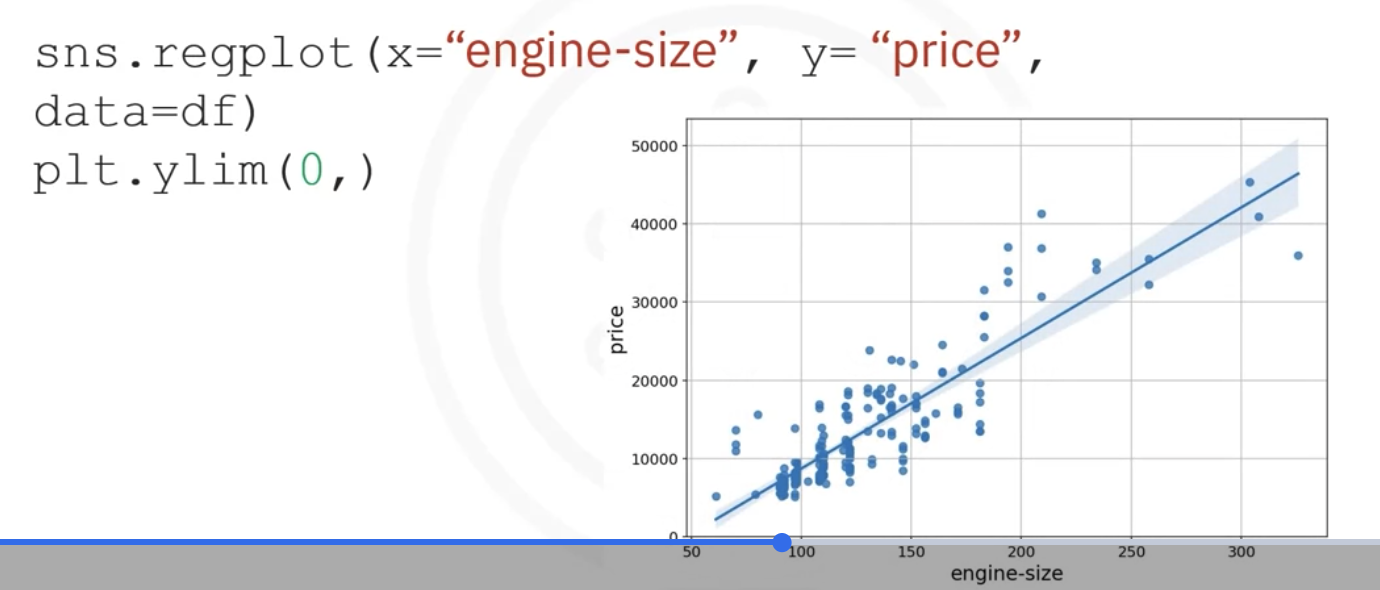

---


### PERSON CORRELATION

### Measure the strength of the correlation between two features:

- Correlation coefficient (Hệ số tương quan)

- P - value (Giá trị P)

### Correlation coefficient 

- Close to +1: Large Positive relationship (Có liên quan với nhau theo chiều thuận - nghĩa là đồng biến)

- Close to -1: Large Negative relationship (Có liên quan với nhau theo chiều nghịch - nghĩa là nghịch biến)

- Close to 0: No Correlation (Không có liên quan gì đến nhau)

### P_value

- P_value < 0.001 : Strong certainty in the result 

- P_value < 0.05 : Moderate certainty in the result 

- P_value < 0.1 : Weak certainty in the result 

- P_value > 0.1 : No certainty in the result

### STRONG CORRELATION IS

- Correlation coefficient close to -1 or 1 

- P value less than 0.001

`Biến 1, Biến 2 = stats.pearsonr(df["Cột muốn xét 1"], df[Cột muốn xét 2])`

Giải thích thêm: 

- `stats.pearsonr()` là hàm từ thư viện **scipy.stats** --> có chức năng đo lường quan hệ tuyến tính giữa hai cột muốn xét

Và điều quan trọng là hàm `pearsonr()` trả về 2 giá trị là Correlation Coefficient và P_value nên chúng ta cần dùng 2 biến để store giá trị

Góc tà đạo: Do hàm sẽ trả về kiểu dữ liệu tuple 

pearsonr_cal = stats.pearsonr(df["One"], df["Two"])
Co_Co = pearsonr_cal[0]
P_value = pearsonr_cal[1]
